# Vector Error Correction Model (VECM) Simulation

## Simulation Procedure

Recall that the VECM is given by,

$
\begin{align}
\Delta X_t &= A_1  X_{t-1} + A_2 X_{t-1}+ \cdots + A_n \Delta X_{t - n + 1}  + \mathcal{E}_t \\
           &= A_1 X_{t-1} + \sum_{i=2}^n A_n \Delta X_{t - n + 1}  + \mathcal{E}_t
\end{align}
\tag{1}
$

where,

$
\begin{align}
\Delta X_t = \left[\Delta x_{1,t}, \Delta x_{2,t}, \ldots, \Delta x_{k,t}\right]^\prime
\end{align}
\tag{2}
$

and $A_i$ are square $k\times k$ matrices and $\mathcal{E}_t$ is a serially uncorrelated random column vector of length $k$ with distribution

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0,\Omega)
\end{align}
\tag{3}
$ 

and covariance matrix for $t=s$,

$
\begin{align}
\text{Cov}\left(\mathcal{E}_t \mathcal{E}_s\right) = \Omega
\end{align}
\tag{3}
$ 

and for $t\ne s$

$
\begin{align}
\text{Cov}\left(\mathcal{E}_t \mathcal{E}_s\right) = 0
\end{align}
\tag{4}
$ 

Cointegration requires

$
\begin{align}
\text{rank}\left(\alpha \beta^\prime\right) r = k
\end{align}
\tag{4}
$ 

here $\alpha$ has order $k\times r$ and $\beta^\prime$ has order $r\times k$

In [16]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import vecm
from lib.plots import comparison, curve

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [43]:
def plot_vecm_simulation(t, xt, λ, β):
    title = f"VECM(2) Simulation"
    labels = [r"$x_1$", r"$x_2$", r"$x_3$"]   
    comparison(xt, t, labels =labels, title=title, xlabel=r"$t", lw=1)

## VECM(2) with Single Cointegrating Vector

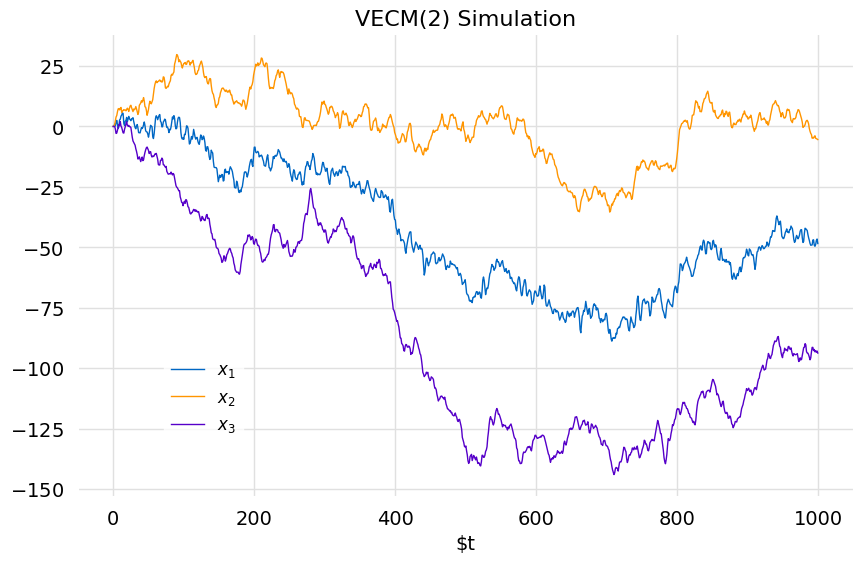

In [42]:
λ = numpy.matrix([-0.5, 0.0, 0.0]).T
β = numpy.matrix([1.0, -0.5, -0.5])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

t, xt = vecm.create_vecm2_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, λ, β)